In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy as sc
import xarray as xr

plt.rcParams.update({'font.size': 12})

# choose colours
uc = "#298c8c"
cc = "#800074"

In [17]:
# load smoothed dataset and vertical velocities

smooth = xr.open_mfdataset("..\\data\\smooth_profiles.nc")
vel = xr.open_mfdataset("..\\data\\vertical_velocity.nc")


In [18]:
# select just the last night (fast sampling)

smooth = smooth.sel(dive_num=slice(53,56), drop=True)
vel = vel.sel(dive_num=slice(53,56), drop=True)

# for other nights: 
# smooth = smooth.sel(dive_num=slice(8,11), drop=True)
# vel = vel.sel(dive_num=slice(8,11), drop=True)

# smooth = smooth.sel(dive_num=slice(18,20), drop=True)
# vel = vel.sel(dive_num=slice(18,20), drop=True)

# smooth = smooth.sel(dive_num=slice(29,32), drop=True)
# vel = vel.sel(dive_num=slice(29,32), drop=True)

# smooth = smooth.sel(dive_num=slice(40,43), drop=True)
# vel = vel.sel(dive_num=slice(40,43), drop=True)

dives = smooth.dive_num.values

In [19]:
# where either ubat or cem is NaN, make both NaN for consistency

ubat_tmp = smooth.ubat_smooth.values.flatten()
cem_tmp = smooth.cem_smooth.values.flatten()

mask = np.isnan(ubat_tmp) | np.isnan(cem_tmp)
ubat_tmp[mask] = np.nan
cem_tmp[mask] = np.nan

ubat_tmp = ubat_tmp.reshape(np.shape(smooth.ubat_smooth.values))
cem_tmp = cem_tmp.reshape(np.shape(smooth.cem_smooth.values))

smooth['ubat_smooth'] = (['dive_num', 'depth'], ubat_tmp)
smooth['cem_smooth'] = (['dive_num', 'depth'], cem_tmp)


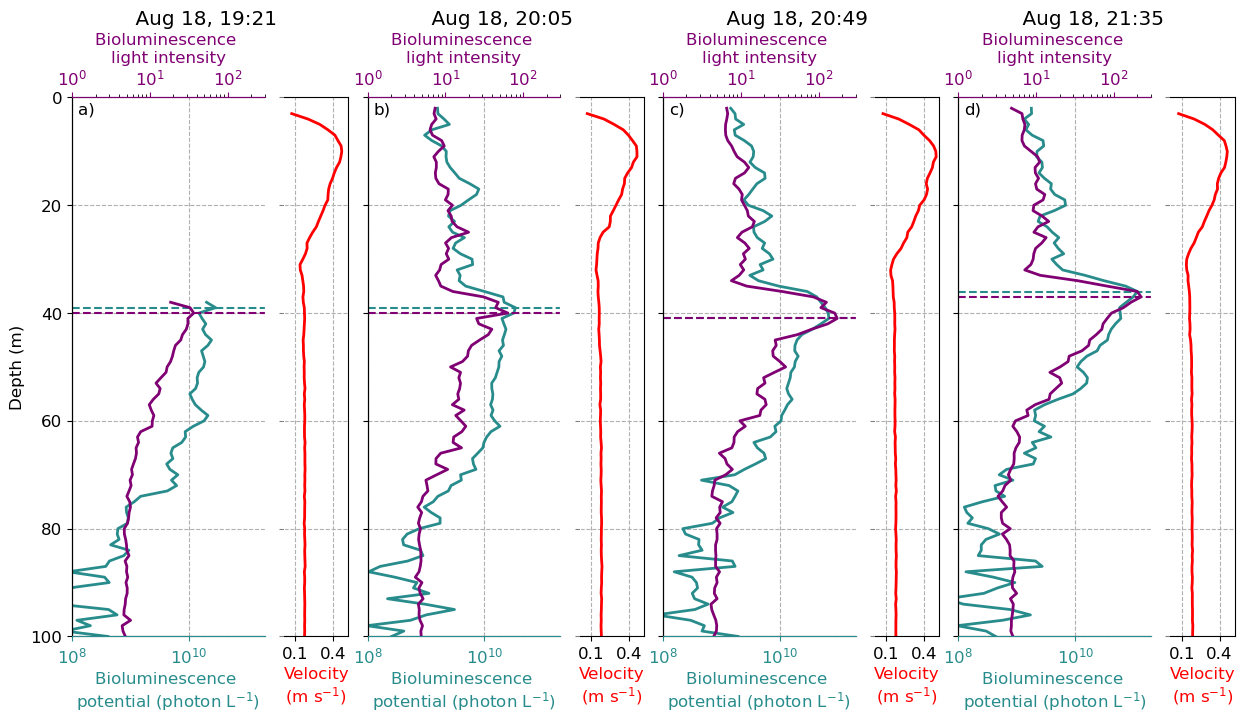

In [20]:
%matplotlib inline

plt.close()
fig, ax = plt.subplots(1,8, figsize=(15,7), sharey=True, gridspec_kw={'width_ratios':[3,1,3,1,3,1,3,1], 'wspace':0.15})

#########################################
# BIOLUMINESCENCE

for j in range(len(dives)):
    i = j*2
    axes = [ax[i], ax[i].twiny()]
    sel = smooth.sel(dive_num=dives[j], depth=slice(0,100))
    ax[i].plot(sel.ubat_smooth, sel.depth, c=uc, lw=2)
    axes[1].plot(sel.cem_smooth, sel.depth, c=cc, lw=2)
    axes[1].set_xscale('log')
    axes[1].set_xlim(1,3e2)

    ax[i].axhline(sel.depth[np.nanargmax(sel.ubat_smooth)].values, c=uc, ls='--')
    ax[i].axhline(sel.depth[np.nanargmax(sel.cem_smooth)].values, c=cc, ls='--')

    ax[i].set_xlabel('Bioluminescence \npotential (photon L$^{-1}$)', color=uc)
    axes[1].set_xlabel('Bioluminescence \nlight intensity', color=cc)
    axes[1].spines['bottom'].set_color(uc)
    axes[1].spines['top'].set_color(cc)
    ax[i].tick_params(axis='x', colors=uc)
    axes[1].tick_params(axis='x', colors=cc)

###########################################
# VELOCITY
    
    k = i+1
    selv = vel.sel(dive_num=dives[j], depth=slice(0,100))
    ax[k].plot(selv.vert_vel, selv.depth, c='r', lw=2)
    ax[k].set_xlabel('Velocity\n(m s$^{-1}$)', color='r')
    ax[k].set_xlim(0.01,0.52)
    ax[k].set_xticks([0.1, 0.4])

    ax[i].spines['right'].set_color('white')
    axes[1].spines['right'].set_color('white')
    ax[k].spines['left'].set_color('white')
    ax[k].grid(ls='--')
    ax[k].tick_params(axis='y', colors='grey')

############################################
# FORMATTING
    
for j in range(4):
    i = j*2
    ax[i].set_xscale('log')
    ax[i].grid(ls='--')
    ax[i].set_xlim(1e8,2e11)

ax[0].set_ylabel('Depth (m)')

ax[0].set_title('            Aug 18, 19:21')
ax[2].set_title('            Aug 18, 20:05')
ax[4].set_title('            Aug 18, 20:49')
ax[6].set_title('            Aug 18, 21:35')

ax[0].text(0.03,0.97, 'a)', transform=ax[0].transAxes)
ax[2].text(0.03,0.97, 'b)', transform=ax[2].transAxes)
ax[4].text(0.03,0.97, 'c)', transform=ax[4].transAxes)
ax[6].text(0.03,0.97, 'd)', transform=ax[6].transAxes)


ax[0].set_ylim(100,0)
plt.show()